In [1]:
%load_ext autoreload
%autoreload 2

import os, h5py
import numpy as np
import matplotlib.pyplot as plt

from msfm.utils import files, parameters, buzzard

from msi.flow_conductor.likelihood_flow import LikelihoodFlow
from msi.flow_conductor import architecture

lensing, clustering, combined = False, False, False

# v16

### lensing

In [2]:
lensing = True
params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]
n_steps = 500_000

file_label = ""

### clustering

In [3]:
# clustering = True
# params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4"]
# n_steps = 500_000

# file_label = ""

### combined

In [4]:
# combined = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]
# n_steps = 500_000

# file_label = ""

In [5]:
msfm_conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v16/default.yaml")
base_dir = "/pscratch/sd/a/athomsen/deep_lss/v16/default/cls"

# constants

In [6]:
buzzard_cosmo = buzzard.get_cosmo(msfm_conf, params)
n_params = len(params)
if lensing:
    probe = "lensing"
elif clustering:
    probe = "clustering"
elif combined:
    probe = "combined"

pred_dir = os.path.join(base_dir, probe, file_label)

pred_file = os.path.join(pred_dir, f"preds_{n_steps}.h5")
print(f"pred_file = {pred_file}")

pred_file = /pscratch/sd/a/athomsen/deep_lss/v16/default/cls/lensing/preds_500000.h5


In [7]:
with h5py.File(pred_file, "r") as f:
    grid_preds = f["grid/preds/test"][:]
    grid_cosmos = f["grid/cosmos/test"][:]

    all_obs_preds = {}
    for key, value in f["obs/preds"].items():
        value = value[:]
        
        print(f"Found observation {key} of shape {value.shape}")
        all_obs_preds[key] = value
    
print(f"grid_preds.shape = {grid_preds.shape}")
print(f"grid_cosmos.shape = {grid_cosmos.shape}")

Found observation DESy3 of shape (12,)
Found observation bench_box_mean of shape (12,)
Found observation bench_box_stack of shape (80, 12)
Found observation bench_fidu_mean of shape (12,)
Found observation bench_fidu_stack of shape (80, 12)
Found observation bench_particle_mean of shape (12,)
Found observation bench_particle_stack of shape (80, 12)
Found observation bench_redshift_mean of shape (12,)
Found observation bench_redshift_stack of shape (80, 12)
grid_preds.shape = (200000, 12)
grid_cosmos.shape = (200000, 6)


# normalizing flow $p(x | \theta)$

### initialization

In [8]:
model = LikelihoodFlow(
    params, 
    msfm_conf, 
    feature_dim=grid_preds.shape[-1],    
    out_dir=pred_dir, 
    label="" if file_label is None else file_label,
    load_existing=True,
)

26-03-04 07:27:46 likelihood_b INF   Set up the model directory /pscratch/sd/a/athomsen/deep_lss/v16/default/cls/lensing/likelihood_flow 
26-03-04 07:27:46 likelihood_f INF   Using the default context embedding network: 
26-03-04 07:27:46 likelihood_f INF   <class 'enflows.nn.nets.resnet.ResidualNet'> 
26-03-04 07:27:46 likelihood_f INF   Using the default base distribution: 
26-03-04 07:27:46 likelihood_f INF   <class 'enflows.distributions.normal.StandardNormal'> 
26-03-04 07:27:46 likelihood_f INF   Using the default transform: 
26-03-04 07:27:46 likelihood_f INF   <class 'enflows.transforms.base.CompositeTransform'> 
26-03-04 07:27:46 likelihood_f INF   Initialized the normalizing flow 
26-03-04 07:27:46 likelihood_f INF   Running on device cuda with default float torch.float32 
26-03-04 07:27:47 likelihood_f INF   Loaded the model from /pscratch/sd/a/athomsen/deep_lss/v16/default/cls/lensing/likelihood_flow/likelihood_flow.pt 


### training

In [9]:
# history = model.fit(
#     x=grid_preds,
#     theta=grid_cosmos,
#     n_epochs=100,
#     batch_size=10_000,
#     scheduler_type="cosine",
#     save_model=True,
#     run_c2st=True,
# )

# observation

## CosmoGrid

### grid

In [10]:
obs_dict = {}

n_examples = 4

for i_grid in range(n_examples):
    # unique cosmological parameters
    i_grid *= msfm_conf["analysis"]["grid"]["n_perms_per_cosmo"] * msfm_conf["analysis"]["n_patches"]
    
    obs_dict[f"grid_{i_grid}"] = {
        "pred": grid_preds[i_grid],
        "cosmo": {str(param): value for param, value in zip(params, grid_cosmos[i_grid])},
    }


### benchmarks

In [11]:
# obs_dict = {}
# obs_cosmo = {str(param): value for param, value in zip(params, parameters.get_fiducials(params, msfm_conf))}

# obs_labels = ["bench_fidu"]
# obs_labels += ["bench_box", "bench_particle", "bench_redshift"]
# # # obs_labels += ["source_clustering_bgs_low", "source_clustering_bgs_high"]
# # # obs_labels = ["fidu_bary", "fidu_dmo"]
# # # obs_labels += ["ia_shell"]

# for obs_label in obs_labels:
#     obs_label += "_mean"
#     obs_preds = all_obs_preds[obs_label]
    
#     obs_dict[obs_label] = {
#         "pred": obs_preds, 
#         "cosmo": obs_cosmo,
#     }


## DES Y3

In [12]:
# obs_dict = {}

# obs_label = "DESy3"

# obs_dict[obs_label] = {
#     "pred": all_obs_preds[obs_label],
#     "cosmo": None,
# }

## Buzzard

In [13]:
# obs_labels = []
# # obs_labels += [f"Buzzard_{i}" for i in [0] + list(range(2, 16))]
# obs_labels += ["Buzzard_mean"]
# # obs_labels += ["Buzzard_stack"]

# for obs_label in obs_labels:
#     obs_preds = all_obs_preds[obs_label]
    
#     obs_dict[obs_label] = {
#         "pred": obs_preds, 
#         "cosmo": obs_cosmo,
#     }

In [14]:
# obs_dict = {}

# # buzzard_indices = list(range(0, 16))
# # buzzard_indices.remove(1)
# buzzard_indices = [0, 2]
# buzzard_stack = []
# for i in buzzard_indices:
#     pred = all_obs_preds[f"Buzzard_{i}"]
#     buzzard_stack.append(pred)
    
#     # obs_dict[f"Buzzard_{i}"] = {
#     #     "pred": pred,
#     #     "cosmo": buzzard_cosmo,
#     # }

# buzzard_stack = np.stack(buzzard_stack, axis=0)

# obs_dict[f"Buzzard_mean"] = {
#     "pred": np.mean(buzzard_stack, axis=0),
#     "cosmo": buzzard_cosmo,
# }

# obs_dict[f"Buzzard_stack"] = {
#     "pred": np.stack(buzzard_stack, axis=0),
#     "cosmo": buzzard_cosmo,
# }

### MCMC and plotting


Starting with mock observation grid_0
26-03-04 07:27:47 likelihood_f INF   Sampling the posterior from a single observation 
26-03-04 07:27:47 likelihood_f WAR   wCDM 
26-03-04 07:27:47      mcmc.py INF   Initial values in prior: 46.9% 
26-03-04 07:27:47      mcmc.py INF   Starting the burn in MCMC chain (1000 steps) 


100%|██████████| 1000/1000 [00:23<00:00, 42.29it/s]

26-03-04 07:28:13      mcmc.py INF   Starting the main MCMC chain (1000 steps) 



100%|██████████| 1000/1000 [00:24<00:00, 40.73it/s]

26-03-04 07:28:37      mcmc.py INF   Saved the MCMC chain to /pscratch/sd/a/athomsen/deep_lss/v16/default/cls/lensing/likelihood_flow/chain_grid_0.npy 


...

  0%|          | 0/21 [00:00<?, ?it/s]

/global/common/software/des/athomsen/torch_env/lib/python3.9/site-packages/trianglechain/make_subplots.py:130: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  axc.plot(


  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

26-03-04 07:31:29  plotting.py INF   Saved the plot to /pscratch/sd/a/athomsen/deep_lss/v16/default/cls/lensing/likelihood_flow/contours_grid_240.png 


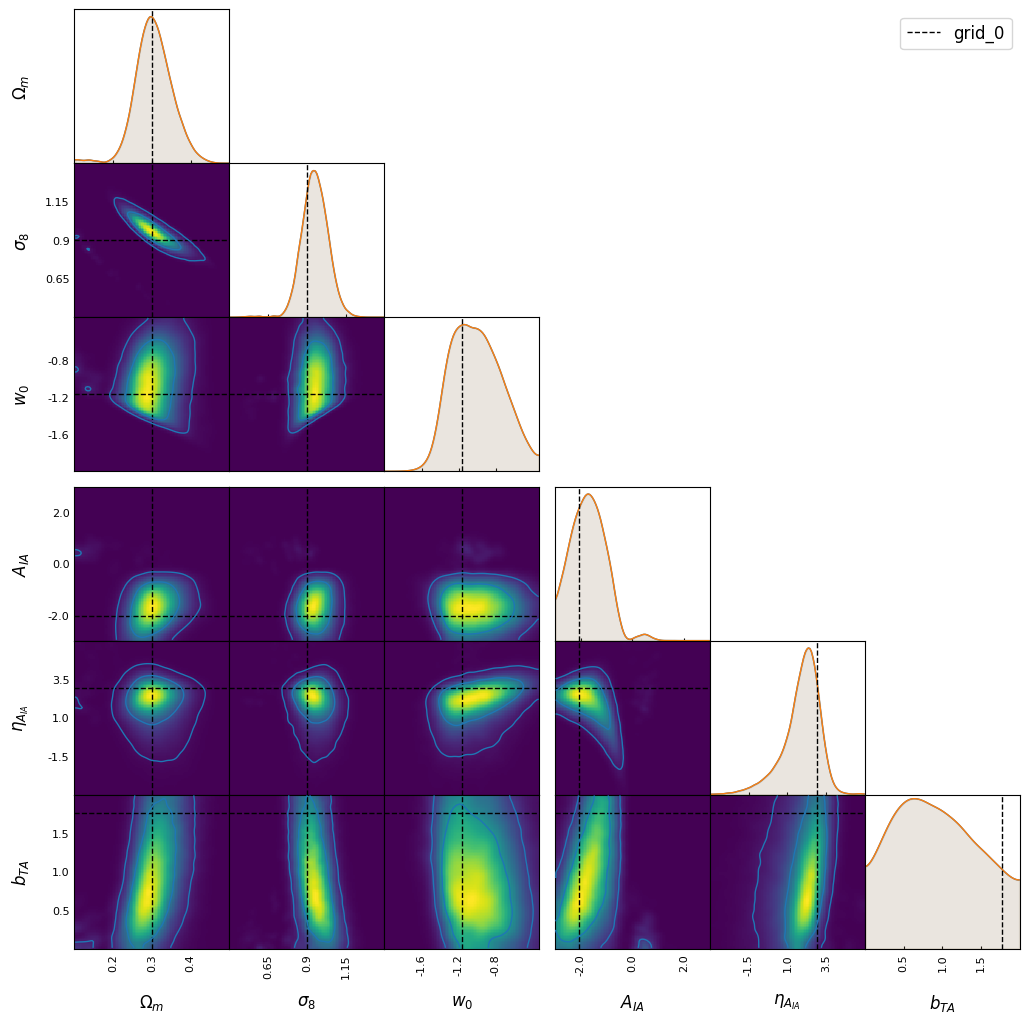

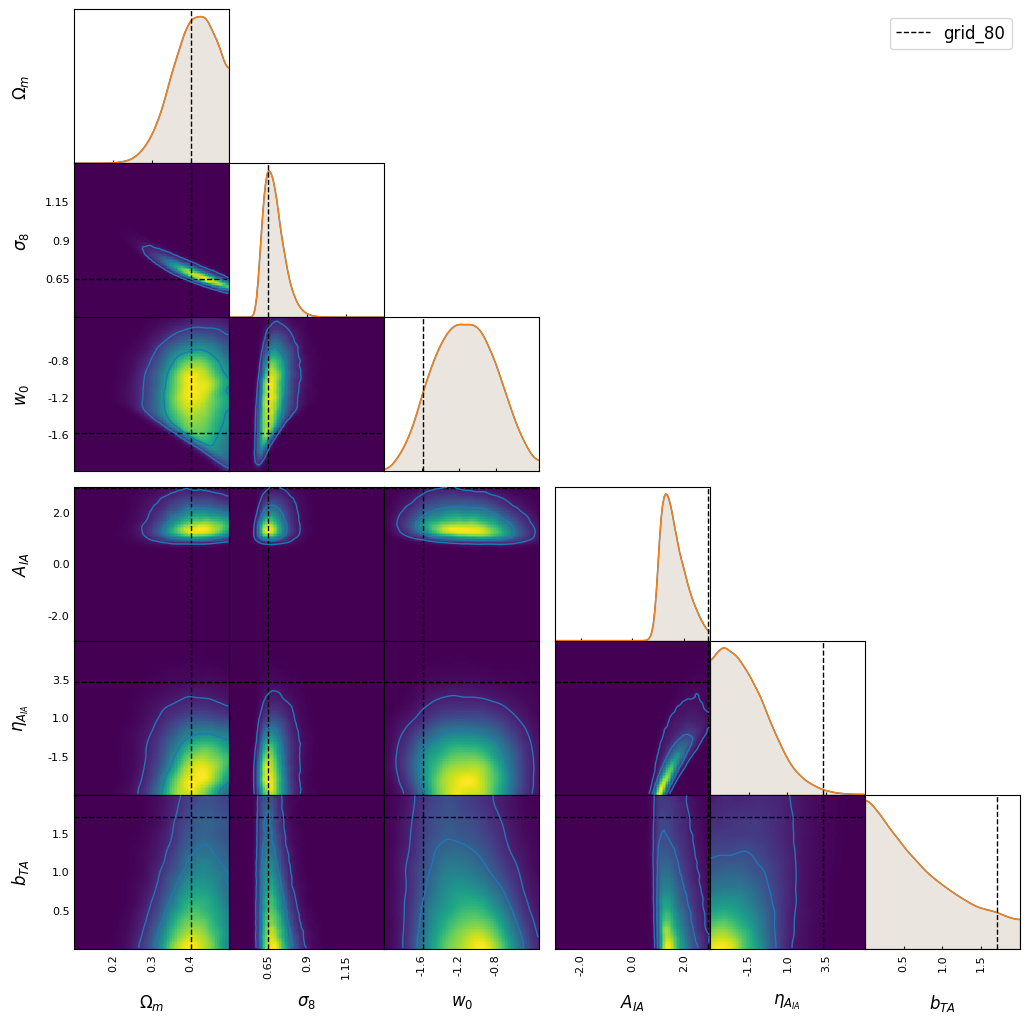

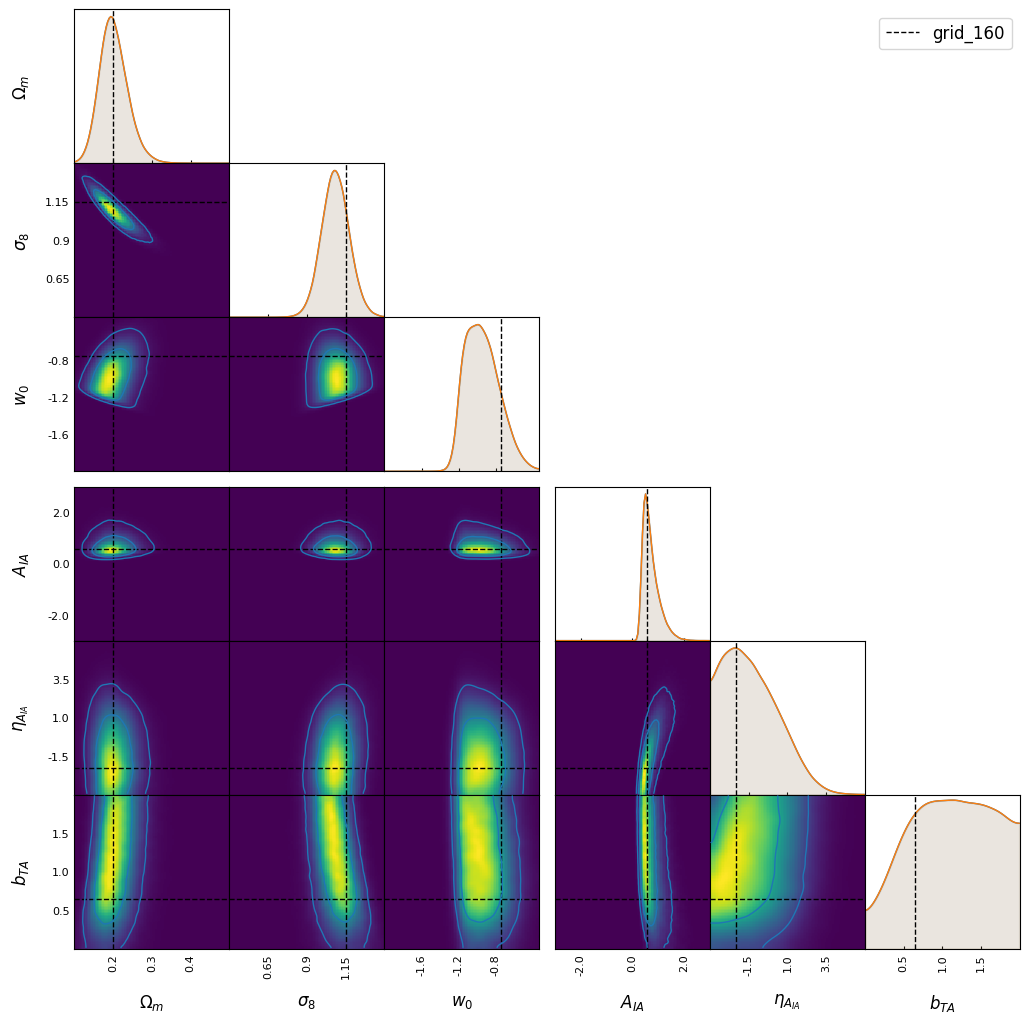

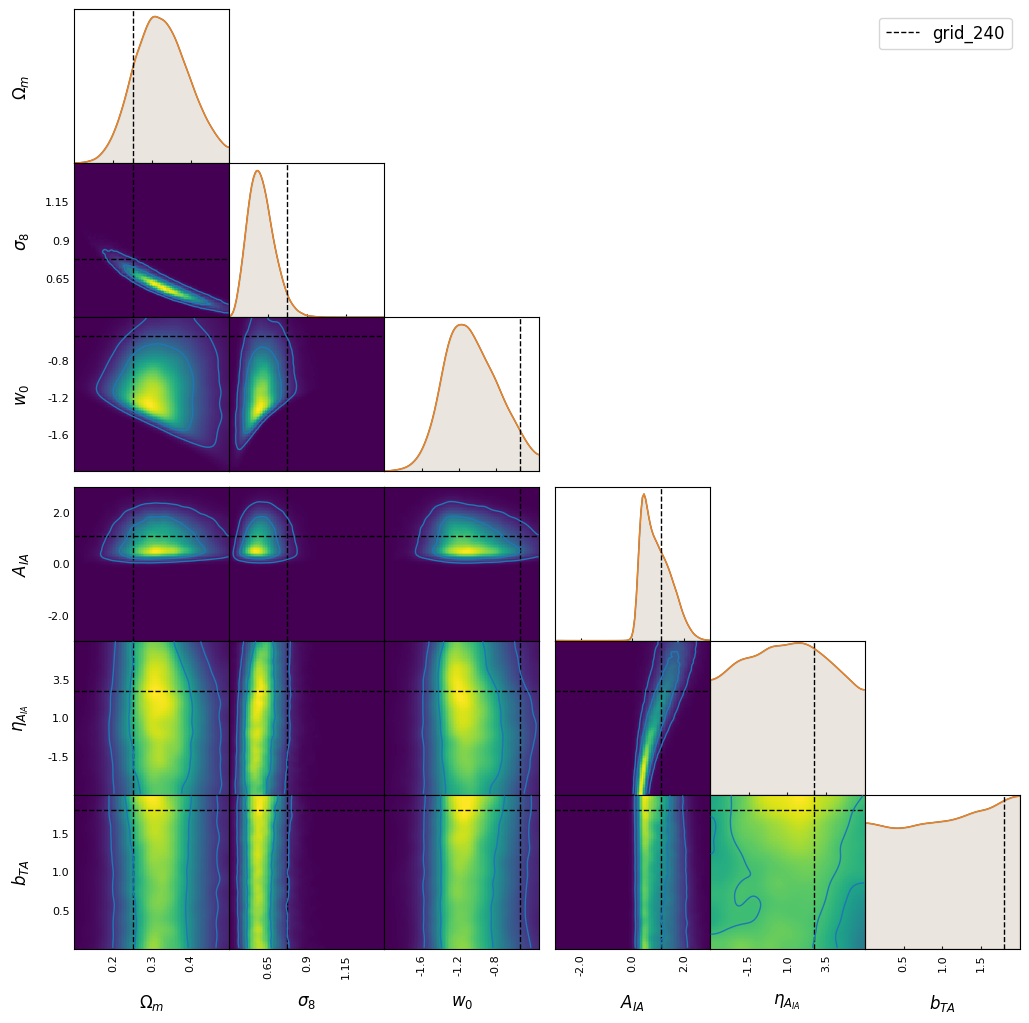

In [15]:
extra_label = ""

for key in obs_dict.keys():
    print(f"\nStarting with mock observation {key}")
    
    posterior_samples = model.sample_posterior(
        obs_dict[key]["pred"],
        label=key+extra_label,
        n_walkers=1024,
        n_steps=1000,
        n_burnin_steps=1000,
    )

    if not "des" in key.lower():
        model.plot_contours(
            posterior_samples,
            obs_point=obs_dict[key]["cosmo"],
            obs_label=key,
            label=key+extra_label,
            with_des_chain=False,
            density=True
        )